Running TRACTS continuous migration model (approximated)...
Running msprime continuous migration simulation...
Extracting tracts...

Continuous migration plots saved!


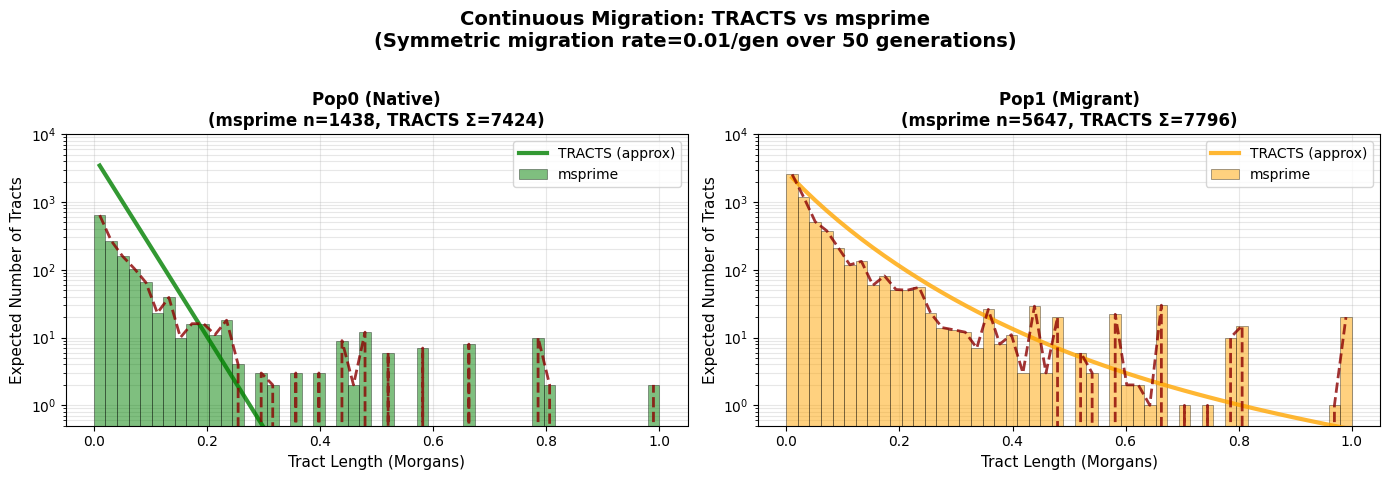


CONTINUOUS MIGRATION SUMMARY
Symmetric migration rate: 0.01/generation
Migration occurs from generation 2 to 50 (TRACTS constraint)
Founding split at generation 50: 50-50

Pop0 (native) tracts in Pop0 samples:
  msprime: n=1438, mean=0.0669 M
  TRACTS: Σ=7424

Pop1 (migrant) tracts in Pop0 samples:
  msprime: n=5647, mean=0.0637 M
  TRACTS: Σ=7796


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import msprime
import tskit
from collections import defaultdict

# Try to import tracts
try:
    import tracts
    HAS_TRACTS = True
except ImportError:
    HAS_TRACTS = False
    print("Warning: tracts not available")

# ============================================================================
# SCENARIO: CONTINUOUS MIGRATION
# Example: Ongoing gene flow between populations
# ============================================================================

# Parameters for continuous migration
t_start = 50  # Migration starts 50 generations ago
migration_rate = 0.01  # 1% per generation migration rate
Ne_cont = 10000
sample_size_cont = 200
sequence_length = 1e8  # 100 Mb = 1 Morgan
r = 1e-8  # Recombination rate
bins = np.linspace(0, 1, 50)
Ls = [1.0]

# ============================================================================
# TRACTS: CONTINUOUS MIGRATION (CORRECTED)
# ============================================================================
def run_tracts_continuous():
    """
    Run TRACTS with continuous migration approximated as discrete pulses
    """
    if not HAS_TRACTS:
        return None, None
    
    # Approximate continuous migration with pulses every generation
    mig = np.zeros((t_start + 1, 2))  # Pop0, Pop1
    
    # FOUNDING EVENT (oldest, at index t_start) must sum to 1.0
    # At t=50, population splits 50-50 between two sources
    mig[t_start, 0] = 0.50
    mig[t_start, 1] = 0.50
    
    # Add small migration pulses each generation (continuous approximation)
    # IMPORTANT: TRACTS doesn't allow migration at generation 0 or 1
    # So we go from generation 2 to t_start-1
    for t in range(2, t_start):
        mig[t, 1] = migration_rate  # Migration from Pop1
    
    # Generation 0 and 1 must have no migration (TRACTS constraint)
    # mig[0, :] = 0  # Already zero
    # mig[1, :] = 0  # Already zero
    
    model = tracts.DemographicModel(mig)
    
    y0 = model.expectperbin(Ls, 0, bins)
    y1 = model.expectperbin(Ls, 1, bins)
    
    y0 = np.array(y0).flatten()[:len(bins)-1]
    y1 = np.array(y1).flatten()[:len(bins)-1]
    
    scaling_factor = 2 * sample_size_cont
    y0_scaled = y0 * scaling_factor
    y1_scaled = y1 * scaling_factor
    
    return y0_scaled, y1_scaled

# ============================================================================
# MSPRIME: CONTINUOUS MIGRATION (Native Support)
# ============================================================================
def run_msprime_continuous(rseed=43):
    """Run msprime with continuous symmetric migration"""
    
    demography = msprime.Demography()
    demography.add_population(name="Pop0", initial_size=Ne_cont)
    demography.add_population(name="Pop1", initial_size=Ne_cont)
    
    # Set symmetric continuous migration between populations
    # Migration happens from generation 0 up to t_start
    demography.set_migration_rate(source="Pop0", dest="Pop1", rate=migration_rate)
    demography.set_migration_rate(source="Pop1", dest="Pop0", rate=migration_rate)
    
    print("Running msprime continuous migration simulation...")
    
    ts = msprime.sim_ancestry(
        samples={"Pop0": sample_size_cont},  # Sample from Pop0
        demography=demography,
        sequence_length=sequence_length,
        recombination_rate=r,
        ploidy=2,
        model="dtwf",
        end_time=t_start,
        record_migrations=True,
        random_seed=rseed
    )
    
    print("Extracting tracts...")
    
    tables = ts.dump_tables()
    migrations = tables.migrations
    num_sample_nodes = 2 * sample_size_cont
    
    z = migrations.node[migrations.node >= num_sample_nodes]
    if z.size > 0:
        linked_edges = ts.tables.link_ancestors(range(num_sample_nodes), np.unique(z))
    else:
        linked_edges = tskit.EdgeTable()
    
    ch_cache = defaultdict(list)
    for edge in linked_edges:
        ch_cache[edge.parent].append(edge)
    
    # Extract migration tracts
    tracts_by_pop = [[], []]  # Pop0, Pop1
    
    for row in migrations:
        if row.node < num_sample_nodes:
            seg_length = row.right - row.left
            tracts_by_pop[row.dest].append(seg_length)
        else:
            children = ch_cache[row.node]
            for child in children:
                seg_length = child.right - child.left
                tracts_by_pop[row.dest].append(seg_length)
    
    tracts_morgans = [np.array(t) / sequence_length for t in tracts_by_pop]
    
    return tracts_morgans[0], tracts_morgans[1]

# ============================================================================
# RUN AND PLOT CONTINUOUS MIGRATION
# ============================================================================

if HAS_TRACTS:
    print("Running TRACTS continuous migration model (approximated)...")
    tracts_pop0, tracts_pop1 = run_tracts_continuous()
else:
    tracts_pop0, tracts_pop1 = None, None

msprime_pop0, msprime_pop1 = run_msprime_continuous(rseed=43)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pop_labels = ['Pop0 (Native)', 'Pop1 (Migrant)']
colors = ['green', 'orange']
msprime_data_cont = [msprime_pop0, msprime_pop1]
tracts_data_cont = [tracts_pop0, tracts_pop1]

for idx, (ax, label, color, msp_tracts, tr_y) in enumerate(
    zip(axes, pop_labels, colors, msprime_data_cont, tracts_data_cont)):
    
    # msprime histogram
    if len(msp_tracts) > 0:
        counts, bin_edges = np.histogram(msp_tracts, bins=bins, density=False)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        bin_width = bin_edges[1] - bin_edges[0]
        
        ax.bar(bin_centers, counts, width=bin_width, 
               alpha=0.5, color=color, edgecolor='black', 
               linewidth=0.5, label='msprime', zorder=2)
        ax.plot(bin_centers, counts, color='darkred', 
                linestyle='--', linewidth=2, alpha=0.8, zorder=4)
    
    # TRACTS
    if HAS_TRACTS and tr_y is not None:
        bin_centers = (bins[:-1] + bins[1:]) / 2
        ax.plot(bin_centers, tr_y, color=color, linewidth=3, 
                label='TRACTS (approx)', alpha=0.8, linestyle='-', zorder=3)
    
    ax.set_yscale('log')
    ax.set_ylim([0.5, 1e4])
    ax.set_xlabel('Tract Length (Morgans)', fontsize=11)
    ax.set_ylabel('Expected Number of Tracts', fontsize=11)
    
    if HAS_TRACTS and tr_y is not None:
        title_str = f'{label}\n(msprime n={len(msp_tracts)}, TRACTS Σ={np.sum(tr_y):.0f})'
    else:
        title_str = f'{label}\n(n={len(msp_tracts)} tracts)'
    ax.set_title(title_str, fontsize=12, fontweight='bold')
    
    ax.grid(True, alpha=0.3, which='both', zorder=1)
    ax.legend(fontsize=10)

plt.suptitle(f'Continuous Migration: TRACTS vs msprime\n' + 
             f'(Symmetric migration rate={migration_rate}/gen over {t_start} generations)',
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.savefig("continuous_migration_comparison.png", dpi=300, bbox_inches='tight')
plt.savefig("continuous_migration_comparison.pdf", bbox_inches='tight')
print("\nContinuous migration plots saved!")
plt.show()

# Statistics
print("\n" + "="*80)
print("CONTINUOUS MIGRATION SUMMARY")
print("="*80)
print(f"Symmetric migration rate: {migration_rate}/generation")
print(f"Migration occurs from generation 2 to {t_start} (TRACTS constraint)")
print(f"Founding split at generation {t_start}: 50-50")

print(f"\nPop0 (native) tracts in Pop0 samples:")
print(f"  msprime: n={len(msprime_pop0)}, mean={np.mean(msprime_pop0) if len(msprime_pop0)>0 else 0:.4f} M")
if HAS_TRACTS and tracts_pop0 is not None:
    print(f"  TRACTS: Σ={np.sum(tracts_pop0):.0f}")

print(f"\nPop1 (migrant) tracts in Pop0 samples:")
print(f"  msprime: n={len(msprime_pop1)}, mean={np.mean(msprime_pop1) if len(msprime_pop1)>0 else 0:.4f} M")
if HAS_TRACTS and tracts_pop1 is not None:
    print(f"  TRACTS: Σ={np.sum(tracts_pop1):.0f}")
print("="*80)

